✔️ Found Tamil Nadu data: tamilnadu
Contents inside tamilnadu: ['0.csv', '1.csv', '10.csv', '11.csv', '12.csv', '13.csv', '14.csv', '15.csv', '16.csv', '17.csv', '18.csv', '19.csv', '2.csv', '20.csv', '21.csv', '22.csv', '23.csv', '24.csv', '25.csv', '26.csv', '27.csv', '28.csv', '29.csv', '3.csv', '30.csv', '31.csv', '32.csv', '33.csv', '34.csv', '35.csv', '36.csv', '4.csv', '5.csv', '6.csv', '7.csv', '8.csv', '9.csv']

✔️ Successfully loaded Tamil Nadu CSV File!
   Name of district \nand wholesale \nmarket  \
0                                        1.0   
1                                        NaN   
2                                        1.0   
3                                        2.0   
4                                        3.0   

                         Unnamed: 1 State \nof \nregu-\nlation  \
0                     CHENNAI \n(4)                        NaN   
1                                1.                         2.   
2                     Chinthadripet         

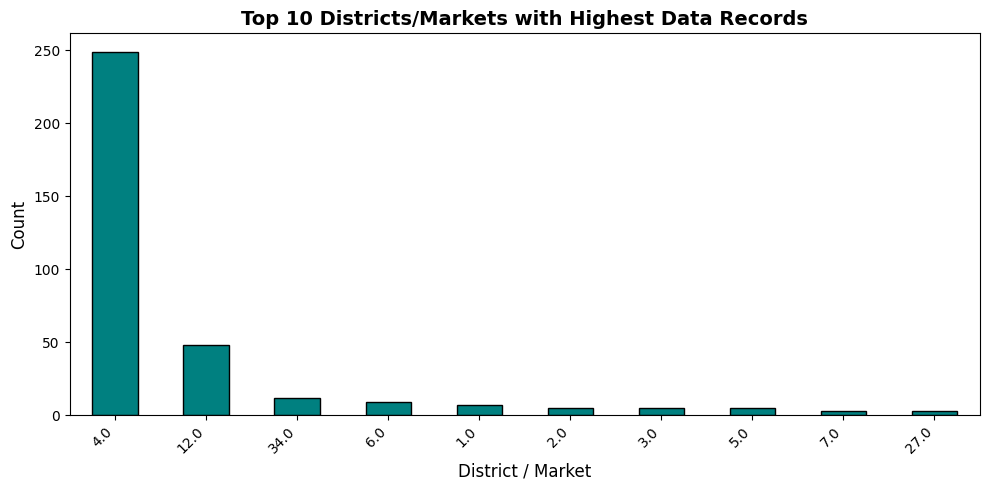

C:\Users\BALA MURALI KRISHNAN\AppData\Local\Temp\ipykernel_20072\4222127632.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_markets.values, y=top_markets.index, ax=axes[0,0], palette='Blues_r')
C:\Users\BALA MURALI KRISHNAN\AppData\Local\Temp\ipykernel_20072\4222127632.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cold_counts.values, y=cold_counts.index, ax=axes[1,0], palette='flare')


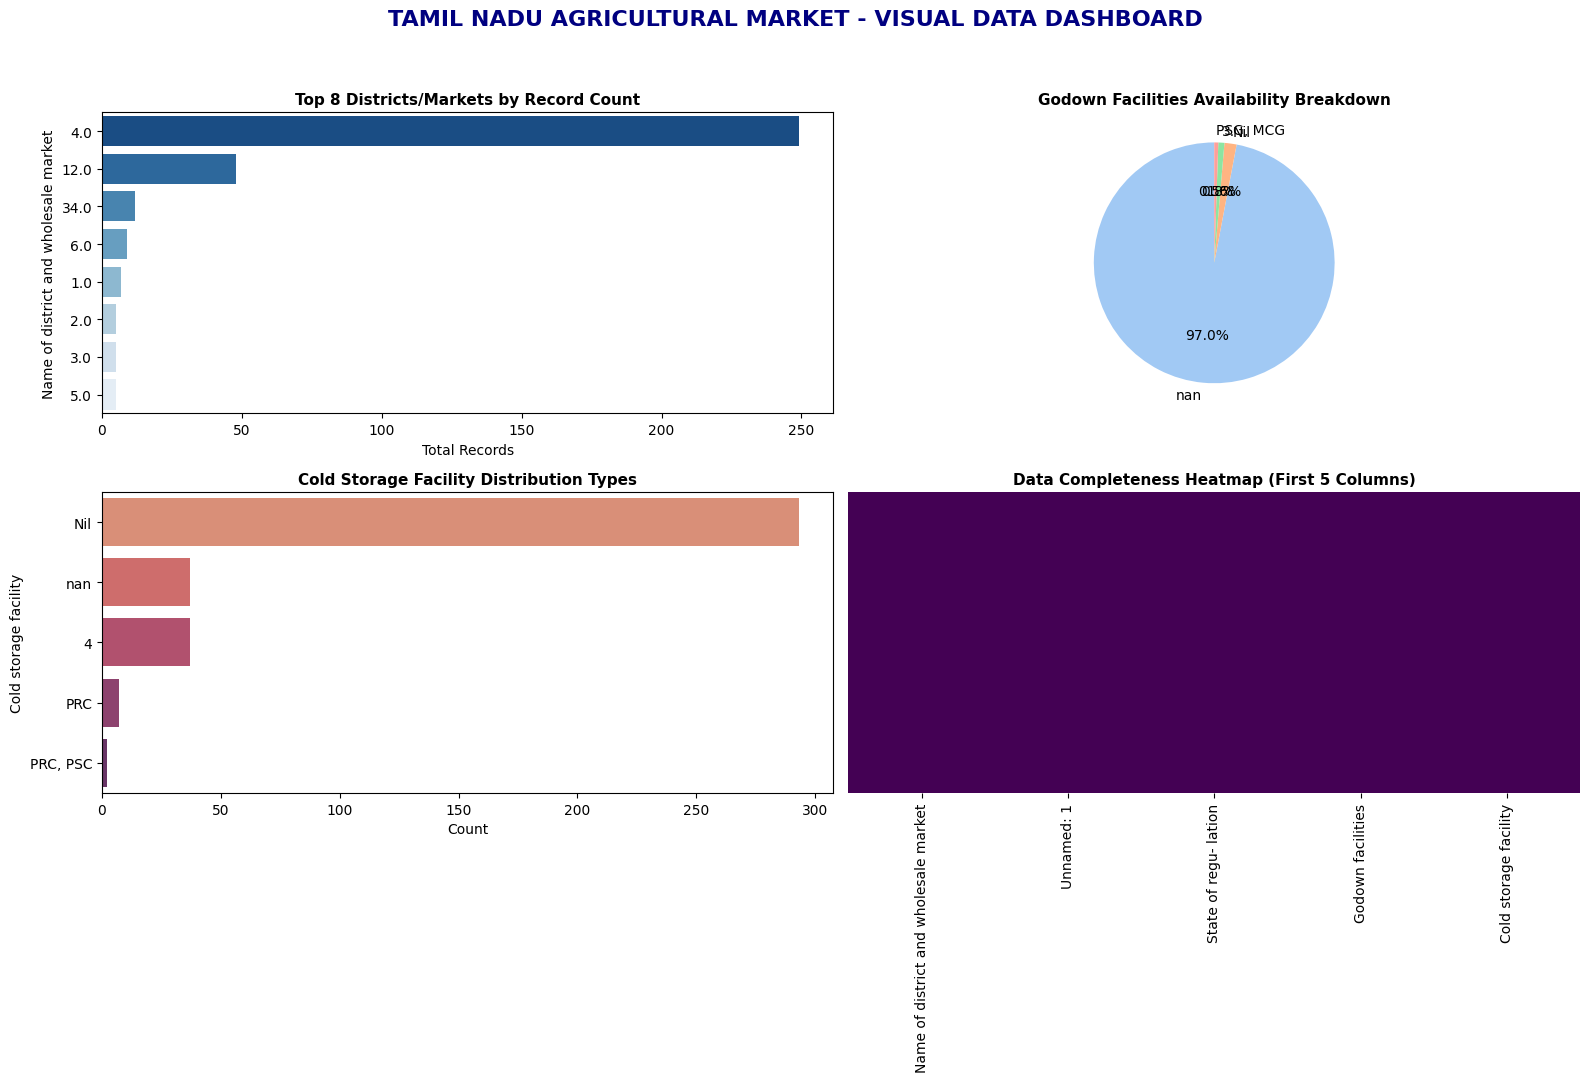

In [1]:
import pandas as pd
import os

# Base directory where the state folders/files are stored
base_path = '../data/archive'

# Checking potential names for Tamil Nadu folder or file
possible_names = ['tamil-nadu', 'tamil_nadu', 'tamilnadu']
tn_file = None

for name in os.listdir(base_path):
    if any(p in name.lower() for p in possible_names):
        tn_file = name
        break

if tn_file:
    full_path = os.path.join(base_path, tn_file)
    print(f"✔️ Found Tamil Nadu data: {tn_file}")
    
    # Check if it's a directory or direct file, and list contents if it's a directory
    if os.path.isdir(full_path):
        print(f"Contents inside {tn_file}:", os.listdir(full_path))
        # If there are CSVs inside, we can pick the first one
        csv_files = [f for f in os.listdir(full_path) if f.endswith('.csv')]
        if csv_files:
            df = pd.read_csv(os.path.join(full_path, csv_files[0]))
            print("\n✔️ Successfully loaded Tamil Nadu CSV File!")
            print(df.head())
    else:
        # If it's a direct file
        df = pd.read_csv(full_path)
        print("\n✔️ Successfully loaded Tamil Nadu Dataset!")
        print(df.head())
else:
    print("❌ Could not find a specific folder or file for Tamil Nadu. Please check the list manually.")
    
import pandas as pd
import os
import glob

# 1. Path to Tamil Nadu directory
tn_dir = '../data/archive/tamilnadu'

# 2. Get all CSV files inside the folder
all_csv_files = glob.glob(os.path.join(tn_dir, "*.csv"))
print(f"Found {len(all_csv_files)} CSV files to merge.")

# 3. Read and combine all files
compiled_list = []
for file in all_csv_files:
    try:
        temp_df = pd.read_csv(file)
        compiled_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {os.path.basename(file)}: {e}")

# Merge everything into one main dataframe
df_merged = pd.concat(compiled_list, ignore_index=True)

# 4. Clean up those messy column names (\n and spaces remove panrom)
df_merged.columns = df_merged.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

print("\n✔️ All files merged successfully!")
print(f"Combined Data Shape: {df_merged.shape}")
print("\nCleaned Column Names:")
print(df_merged.columns.tolist())

# Show a quick preview
print("\nFirst 5 rows of merged data:")
df_merged.head()

# Create a fresh copy
df_clean = df_merged.copy()

# Ore line-la string objects mattum select panni '\n' and extra spaces-ah clear panrom
df_clean = df_clean.apply(lambda x: x.astype(str).str.replace(r'\n', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip() if x.dtype == "object" else x)

print("✔️ Cleaned completely without any errors!")

# Display preview
df_clean.iloc[:, :5].head()

import numpy as np

# 1. Replace the text '- do -' with actual NaN values so pandas can forward-fill them
df_clean = df_clean.replace(r'^- do -$|^– do –$', np.nan, regex=True)

# 2. Forward fill (mela irukra district/market value-va keela irukra empty cells-ku fill panrom)
df_clean = df_clean.ffill()

print("✔️ Missing values and '- do -' entries forward-filled successfully!")

# Let's see the same preview now
df_clean.iloc[:, :5].head()

import matplotlib.pyplot as plt

# 1. Force convert the first column explicitly to a 1D Pandas Series using .iloc
first_column_series = df_clean.iloc[:, 0].astype(str)

print("✔️ Safely isolated the target column for plotting!")

# 2. Get the value counts of the top 10 markets/districts
data_counts = first_column_series.value_counts().head(10)

# 3. Plotting the chart
plt.figure(figsize=(10, 5))
data_counts.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Top 10 Districts/Markets with Highest Data Records', fontsize=14, fontweight='bold')
plt.xlabel('District / Market', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolating data columns using safe positional index sequences (.iloc)
col_0 = df_clean.iloc[:, 0].astype(str)  # Markets / Districts
col_3 = df_clean.iloc[:, 3].astype(str)  # Godown facilities 
col_4 = df_clean.iloc[:, 4].astype(str)  # Cold storage facility

# 2. Setup a clean 2x2 grid dashboard framework
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('TAMIL NADU AGRICULTURAL MARKET - VISUAL DATA DASHBOARD', fontsize=16, fontweight='bold', color='navy')

# --- CHART 1: Top Markets (Horizontal Bar) ---
top_markets = col_0.value_counts().head(8)
sns.barplot(x=top_markets.values, y=top_markets.index, ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Top 8 Districts/Markets by Record Count', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Total Records')

# --- CHART 2: Godown Facilities (Pie Chart) ---
godown_counts = col_3.value_counts().head(4)
axes[0,1].pie(godown_counts.values, labels=godown_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axes[0,1].set_title('Godown Facilities Availability Breakdown', fontsize=11, fontweight='bold')

# --- CHART 3: Cold Storage Distribution (Count Plot) ---
cold_counts = col_4.value_counts().head(5)
sns.barplot(x=cold_counts.values, y=cold_counts.index, ax=axes[1,0], palette='flare')
axes[1,0].set_title('Cold Storage Facility Distribution Types', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Count')

# --- CHART 4: Data Completeness Heatmap ---
# First 5 columns oda missing value structure display panrom
sns.heatmap(df_clean.iloc[:, :5].isnull(), cbar=False, ax=axes[1,1], cmap='viridis', yticklabels=False)
axes[1,1].set_title('Data Completeness Heatmap (First 5 Columns)', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()